# Query The Database for Facts to check on Judge

In [ ]:
import os
import pandas as pd
from neo4j import GraphDatabase
from typing import Dict, List

# =========================
# Neo4j Configuration
# =========================
NEO4J_URI = os.environ["NEO4J_URL"]
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = os.environ["NEO4J_PASSWORD"]

INPUT_CSV = "test/30_questions_sample.csv"
OUTPUT_CSV = "kg_query_results_1.csv"


# =========================
# Helper Functions
# =========================
def normalize_record(record: Dict) -> Dict:
    """
    Convert Neo4j record values to strings
    so they are CSV + LLM friendly.
    """
    normalized = {}
    for k, v in record.items():
        if isinstance(v, list):
            normalized[k] = "; ".join(str(x) for x in v)
        else:
            normalized[k] = "" if v is None else str(v)
    return normalized


def run_cypher_query(tx, query: str) -> List[Dict]:
    """
    Execute a Cypher query and return all rows as dicts.
    """
    result = tx.run(query)
    return [normalize_record(dict(r)) for r in result]


# =========================
# Main Execution
# =========================
def main():
    df = pd.read_csv(INPUT_CSV, delimiter=',')

    driver = GraphDatabase.driver(
        NEO4J_URI,
        auth=(NEO4J_USER, NEO4J_PASSWORD)
    )

    all_outputs = []

    with driver.session() as session:
        for idx, row in df.iterrows():
            cypher = row["cypher"]
            question = row.get("question", f"Q{idx+1}")

            try:
                records = session.execute_read(run_cypher_query, cypher)

                if not records:
                    all_outputs.append({
                        "question": question,
                        "cypher": cypher,
                        "result": ""
                    })
                else:
                    for rec in records:
                        output_row = {
                            "question": question,
                            "cypher": cypher,
                            **rec
                        }
                        all_outputs.append(output_row)

            except Exception as e:
                all_outputs.append({
                    "question": question,
                    "cypher": cypher,
                    "error": str(e)
                })

    driver.close()

    output_df = pd.DataFrame(all_outputs)
    output_df.to_csv(OUTPUT_CSV, index=False)

    print(f"Execution completed. Results saved to {OUTPUT_CSV}")


if __name__ == "__main__":
    main()


Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `RELATIONSHIP` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=33, offset=32>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 32, 'line': 1, 'column': 33}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (c:Entity {type:'ORG'})-[:RELATIONSHIP {type:'Produces'}]->(p:Entity {type:'PRODUCT'}) WHERE p.name CONTAINS 'consumer electronics' RETURN c.name"
Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The re

Execution completed. Results saved to kg_query_results_1.csv


# Running LLM as  judge script to evaluated our models

In [ ]:
import pandas as pd
import csv


def explode_and_merge_results_indexed(
    results_csv, 
    expected_csv,
    output_csv,
    question_col="Question",
    result_col="Result",
    expected_col="Expected"
):
    """
    Explode multi-line results and merge with expected answers using index iteration.
    Matches questions by iterating through both lists simultaneously.
    
    Parameters:
    -----------
    results_csv : str
        Path to CSV with model results (may have multi-line results)
    expected_csv : str
        Path to CSV with expected answers
    output_csv : str
        Path to output CSV with exploded and merged results
    question_col : str
        Column name for questions
    result_col : str
        Column name for results to explode
    expected_col : str
        Column name for expected answers
    
    Returns:
    --------
    pd.DataFrame
        Merged and exploded dataframe
    """
    
    # Load both files
    results_df = pd.read_csv(results_csv)
    expected_df = pd.read_csv(expected_csv)
    
    exploded_rows = []
    expected_idx = 0  # Index for expected answers
    
    for results_idx, row in results_df.iterrows():
        question = row[question_col]
        result = str(row[result_col])
        
        # Split by newline and filter empty strings
        result_lines = [line.strip() for line in result.split('\n') if line.strip()]
        
        # If no lines found, keep original
        if not result_lines:
            result_lines = [result]
        
        # Get expected answer - match by question
        expected_question = expected_df.iloc[expected_idx][question_col] if expected_idx < len(expected_df) else ""
        
        # If questions match, use this expected answer
        if expected_idx < len(expected_df) and question == expected_question:
            expected_answer = expected_df.iloc[expected_idx][expected_col]
            expected_idx += 1  # Move to next expected answer
        else:
            expected_answer = ""
            print(f"[WARNING] Question mismatch at index {results_idx}: '{question}'")
        
        # Create a row for each result line with the same expected answer
        for result_line in result_lines:
            new_row = row.copy()
            new_row[result_col] = result_line
            new_row["expected"] = expected_answer
            exploded_rows.append(new_row)
    
    # Create new dataframe
    exploded_df = pd.DataFrame(exploded_rows).reset_index(drop=True)
    
    # Save to CSV
    exploded_df.to_csv(output_csv, index=False, quoting=csv.QUOTE_ALL)
    
    print(f"\n{'='*70}")
    print(f"EXPLOSION & MERGE SUMMARY")
    print(f"{'='*70}")
    print(f"Original result rows: {len(results_df)}")
    print(f"Exploded rows: {len(exploded_df)}")
    print(f"Expected rows processed: {expected_idx}")
    print(f"Unique questions: {exploded_df[question_col].nunique()}")
    print(f"Expected answers merged: {(exploded_df['expected'] != '').sum()}")
    print(f"Missing expected answers: {(exploded_df['expected'] == '').sum()}")
    print(f"Results saved to {output_csv}")
    print(f"{'='*70}\n")
    
    return exploded_df



In [ ]:
# # Usage example:
# exploded_merged = explode_and_merge_results_indexed(
#     results_csv="results_30questions.csv",
#     expected_csv="test/30_questions_sample.csv",
#     output_csv="results_30questions_exploded_with_expected.csv",
#     question_col="questions",
#     result_col="result",
#     expected_col="expected"
# )

# display(exploded_merged.head(10))
# print(f"Shape: {exploded_merged.shape}")

In [37]:
question = exploded_merged[["questions","expected"]]
answer = exploded_merged[["result"]].rename(columns={"result":"output"})
question.to_csv("questions_exploded.csv",index=False)
answer.to_csv("gemini_2_5_flash_output_pipeline1.csv",index=False)

In [24]:

# Usage example:
exploded_merged = explode_and_merge_results_indexed(
    results_csv="result_pipeline2.csv",
    expected_csv="test/30_questions_sample.csv",
    output_csv="results_pipeline2_30questions_exploded_with_expected.csv",
    question_col="questions",
    result_col="result",
    expected_col="expected"
)



EXPLOSION & MERGE SUMMARY
Original result rows: 30
Exploded rows: 58
Expected rows processed: 30
Unique questions: 30
Expected answers merged: 58
Missing expected answers: 0
Results saved to results_pipeline2_30questions_exploded_with_expected.csv



In [25]:
# question = exploded_merged[["questions","expected"]]
answer = exploded_merged[["result"]].rename(columns={"result":"output"})
# question.to_csv("questions_exploded_pipelin.csv",index=False)
answer.to_csv("gemini_2_5_flash_output_pipeline2.csv",index=False)

In [38]:
from llm_judge import classifer_judge
from judges.classifiers.correctness import PollMultihopCorrectness, PollZeroShotCorrectness

questions_path = "questions_exploded.csv"
answers_path = "gemini_2_5_flash_output_pipeline1.csv"
model = "ollama/gpt-oss:20b"
uid = "pipeline1_pollmultihop_exploded" # Change this

correctness_judge = PollMultihopCorrectness(model=model)

evaluators = {
    "correctness": correctness_judge
}

# Sanitize model name for filename (replace "/" with "_")
safe_model_name = model.replace("/", "_")
results_df = classifer_judge(questions_path,answers_path,evaluators,save_result=True,save_name=f"{safe_model_name}_judge_{uid}.csv")

[INFO] Loaded 60 question-answer pairs
[INFO] Model ollama/gpt-oss:20b is evaluating correctness using PollMultihopCorrectness()...


Evaluating correctness:  37%|███▋      | 22/60 [09:56<25:44, 40.64s/it]

[ERROR] Error at index 21 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'judgments': [{'score': ...core_type': 'boolean'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'judgments': [{'score': ...core_type': 'boolean'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-282', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "judgments": [\n    {\n      "score": true,\n      "reasoning": "The provided answer correctly states that George Washington left office on March 4, 1797, matching the reference date.",\n      "score_type": "boolean"\n    },\n    {\n      "score": false,\n      "reasoning": "The reference answe

Evaluating correctness:  70%|███████   | 42/60 [28:10<37:16, 124.24s/it]  

[ERROR] Error at index 41 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'judgments': [{'REASONIN...pany', 'SCORE': False}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'judgments': [{'REASONIN...pany', 'SCORE': False}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-667', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"judgments":[{"REASONING":"Matches reference date","SCORE":true},{"REASONING":"Does not match reference location","SCORE":false},{"REASONING":"Matches reference area","SCORE":true},{"REASONING":"Does not match reference mayor","SCORE":false},{"REASONING":"Matches reference letter","SCORE":true},{"R

...

[ERROR] Error at index 47 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'judgments': [{'reasonin...ric.', 'score': False}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'judgments': [{'reasonin...ric.', 'score': False}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-657', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "judgments": [\n    {\n      "reasoning": "Answer includes the correct date March 4, 1797.",\n      "score": true\n    },\n    {\n      "reasoning": "Answer does not match the reference location.",\n      "score": false\n    },\n    {\n      "reasoning": "Answer includes the correct area 310 sq

Evaluating correctness:  97%|█████████▋| 58/60 [41:48<02:50, 85.47s/it]

[ERROR] Error at index 57 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'REASONING': ['Provided ...lse', 'False', 'False']}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'REASONING': ['Provided ...lse', 'False', 'False']}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-576', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "REASONING": [\n    "Provided answer includes the correct date March\u202f4,\u202f1797, matching the reference.",\n    "Provided answer gives a location (Bhaktivedanta Manor), but the reference answer is not a location; it is the question itself. Therefore the answer is not correct.",\n    "Pro

Evaluating correctness: 100%|██████████| 60/60 [42:15<00:00, 42.26s/it]

[INFO] Results saved to ollama_gpt-oss:20b_judge_pipeline1_pollmultihop_exploded.csv

EVALUATION RESULTS REPORT
Total Questions Evaluated: 60
Total Evaluation Time: 2535.85s (42.26 minutes)

----------------------------------------------------------------------
METRIC SCORES:
----------------------------------------------------------------------
  Correctness     | Mean: 0.25 | Std: 0.44 | Min: 0.00 | Max: 1.00
----------------------------------------------------------------------
  Overall Average | Mean: 0.25 | Std: 0.44



In [ ]:
results_df.head()

,questions,expected,cypher,output,correctness_score,correctness_reasoning,average_score
0,Which company produces consumer electronics ac...,Apple Inc.,MATCH (c:Entity {type:'ORG'})-[:RELATIONSHIP {...,Apple Inc. (AAPL) is a multinational technolog...,1,The provided answer correctly states that Appl...,1.0
1,What products is Apple Inc. described as produ...,Consumer electronics,MATCH (c:Entity {name:'Apple Inc.'})-[:RELATIO...,Apple Inc. (AAPL) is a multinational technolog...,1,"The provided answer includes the phrase ""consu...",1.0
2,What is the stock ticker associated with Apple...,AAPL,MATCH (c:Entity {name:'Apple Inc.'}) RETURN c....,Company: Apple Inc. | Ticker: AAPL | SourceURL...,1,The answer correctly states that the 2‑digit n...,1.0
3,Which geographic region has Apple Inc. investe...,United States,MATCH (c:Entity {name:'Apple Inc.'})-[:RELATIO...,No results found,0,"The provided answer states no results found, b...",0.0
4,Which financial metric reached an all-time hig...,Services unit revenue,MATCH (c:Entity {name:'Apple Inc.'})-[:RELATIO...,its services unit's revenue set an all-time hi...,0,Evaluated each of the eight questions: Questio...,0.0


In [14]:
from llm_judge import classifer_judge
from judges.classifiers.correctness import PollMultihopCorrectness, PollZeroShotCorrectness, PollKiltNQCorrectness

questions_path = "questions_exploded.csv"
answers_path = "gemini_2_5_flash_output_pipeline1.csv"
model = "ollama/gpt-oss:20b"
uid = "pipeline1_pollkiltnq" # Change this

#correctness_judge = PollMultihopCorrectness(model=model)
correctness_judge = PollKiltNQCorrectness(model=model)

evaluators = {
    "correctness": correctness_judge
}

# Sanitize model name for filename (replace "/" with "_")
safe_model_name = model.replace("/", "_")
results_df = classifer_judge(questions_path,answers_path,evaluators,save_result=True,save_name=f"{safe_model_name}_judge_{uid}.csv")

/home/dang/miniconda3/envs/kg-improved/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded 60 question-answer pairs
[INFO] Model ollama/gpt-oss:20b is evaluating correctness using PollKiltNQCorrectness()...


Evaluating correctness:  18%|█▊        | 11/60 [02:48<18:29, 22.64s/it]

[ERROR] Error at index 10 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'judgments': [{'score': ...core_type': 'boolean'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'judgments': [{'score': ...core_type': 'boolean'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-381', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "judgments": [\n    {\n      "score": true,\n      "reasoning": "The provided answer states 2007, which matches the reference answer \'since 2007\'.",\n      "score_type": "boolean"\n    },\n    {\n      "score": true,\n      "reasoning": "The provided answer identifies Texas as the state with 

Evaluating correctness:  35%|███▌      | 21/60 [05:03<09:03, 13.94s/it]

...

[ERROR] Error at index 21 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'REASONING': 'I evaluate...e correct.', 'SCORE': 5}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'REASONING': 'I evaluate...e correct.', 'SCORE': 5}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-519', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"REASONING":"I evaluated each of the 11 provided answers against the reference answers. Five answers (Q1, Q2, Q3, Q8, Q9) matched the reference and were marked True. Six answers (Q4, Q5, Q6, Q7, Q10, Q11) did not match and were marked False. Therefore, 5 out of 11 answers are correct.","SCORE":5}',

Evaluating correctness:  58%|█████▊    | 35/60 [08:23<06:04, 14.57s/it]

[ERROR] Error at index 34 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'REASONING': 'I evaluate...e correct.', 'SCORE': 5}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'REASONING': 'I evaluate...e correct.', 'SCORE': 5}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-633', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"REASONING":"I evaluated each of the 11 provided answers against the corresponding reference answer. Five answers (Questions 1, 2, 3, 8, and 9) correctly matched the reference information, while the remaining six answers (Questions 4, 5, 6, 7, 10, and 11) did not. Therefore, 5 out of 11 answers are

Evaluating correctness: 100%|██████████| 60/60 [15:56<00:00, 15.95s/it]

[INFO] Results saved to ollama_gpt-oss:20b_judge_pipeline1_pollkiltnq.csv

EVALUATION RESULTS REPORT
Total Questions Evaluated: 60
Total Evaluation Time: 957.01s (15.95 minutes)

----------------------------------------------------------------------
METRIC SCORES:
----------------------------------------------------------------------
  Correctness     | Mean: 0.05 | Std: 0.22 | Min: 0.00 | Max: 1.00
----------------------------------------------------------------------
  Overall Average | Mean: 0.05 | Std: 0.22



In [32]:
from llm_judge import classifer_judge
from judges.classifiers.correctness import PollMultihopCorrectness, PollZeroShotCorrectness

questions_path = "questions_exploded.csv"
# answers_path = "gemini_2_5_flash_output_pipeline2.csv"
manswers_path = "gemini_2_5_flash_output_pipeline1.csv"
model = "ollama/gpt-oss:20b"
uid = "pipeline2_pollzeroshot" # Change this

#correctness_judge = PollMultihopCorrectness(model=model)
correctness_judge = PollZeroShotCorrectness(model=model)

evaluators = {
    "correctness": correctness_judge
}

# Sanitize model name for filename (replace "/" with "_")
safe_model_name = model.replace("/", "_")
results_df = classifer_judge(questions_path,answers_path,evaluators,save_result=True,save_name=f"{safe_model_name}_judge_{uid}.csv")

[INFO] Loaded 60 question-answer pairs
[INFO] Model ollama/gpt-oss:20b is evaluating correctness using PollZeroShotCorrectness()...


Evaluating correctness: 100%|██████████| 60/60 [03:38<00:00,  3.64s/it]

[INFO] Results saved to ollama_gpt-oss:20b_judge_pipeline2_pollzeroshot.csv

EVALUATION RESULTS REPORT
Total Questions Evaluated: 60
Total Evaluation Time: 218.14s (3.64 minutes)

----------------------------------------------------------------------
METRIC SCORES:
----------------------------------------------------------------------
  Correctness     | Mean: 0.08 | Std: 0.28 | Min: 0.00 | Max: 1.00
----------------------------------------------------------------------
  Overall Average | Mean: 0.08 | Std: 0.28



In [27]:
from llm_judge import classifer_judge
from judges.classifiers.correctness import PollKiltHotpotCorrectness

questions_path = "questions_exploded.csv"
answers_path = "gemini_2_5_flash_output_pipeline2.csv"
# answers_path = "gemini_2_5_flash_output_pipeline1.csv"
model = "ollama/gpt-oss:20b"
uid = "pipeline1_pollkilthotpot" # Change this

#correctness_judge = PollMultihopCorrectness(model=model)
correctness_judge = PollKiltHotpotCorrectness(model=model)

evaluators = {
    "correctness": correctness_judge
}

# Sanitize model name for filename (replace "/" with "_")
safe_model_name = model.replace("/", "_")
results_df = classifer_judge(questions_path,answers_path,evaluators,save_result=True,save_name=f"{safe_model_name}_judge_{uid}.csv")

[INFO] Loaded 60 question-answer pairs
[INFO] Model ollama/gpt-oss:20b is evaluating correctness using PollKiltHotpotCorrectness()...


Evaluating correctness:   0%|          | 0/60 [00:00<?, ?it/s]

Evaluating correctness:   2%|▏         | 1/60 [05:42<5:37:07, 342.84s/it]

[ERROR] Error at index 0 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'judgments': [{'score': ...'score_type': 'boolean'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'judgments': [{'score': ...'score_type': 'boolean'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-670', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "judgments": [\n    {\n      "score": false,\n      "reasoning": "The provided answer does not identify Serri as an actor, whereas the reference answer is \\"Serri\\".",\n      "score_type": "boolean"\n    },\n    {\n      "score": true,\n      "reasoning": "The provided answer correctly states 

Evaluating correctness: 100%|██████████| 60/60 [20:24<00:00, 20.42s/it]  

[ERROR] Error at index 59 for correctness: <failed_attempts>

<generation number="1">
<exception>
    2 validation errors for Judgment
score
  Field required [type=missing, input_value={'judgments': [{'score': ...core_type': 'boolean'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
reasoning
  Field required [type=missing, input_value={'judgments': [{'score': ...core_type': 'boolean'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
</exception>
<completion>
    ChatCompletion(id='chatcmpl-695', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"judgments":[{"score":false,"reasoning":"Provided answer does not match the reference answer.","score_type":"boolean"},{"score":true,"reasoning":"Provided answer matches the reference answer.","score_type":"boolean"},{"score":false,"reasoning":"Provided answer does not match the reference answer.",

# Human Annotation Evaluation

Adjusting human annotation alignment.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_agreement_metrics(csv_file_path, human_col="human_correct", model_col="correctness_score"):
    """
    Calculate multiple agreement metrics between human annotators and model predictions.
    
    Parameters:
    -----------
    csv_file_path : str
        Path to CSV file with human and model judgments
    human_col : str
        Column name for human annotations
    model_col : str
        Column name for model predictions
    
    Returns:
    --------
    dict : Dictionary containing all agreement metrics and their interpretations
    """
    
    # Load data
    df = pd.read_csv(csv_file_path)
    
    # Extract columns
    human_scores = df[human_col].values
    model_scores = df[model_col].values
    
    # Handle missing values
    valid_idx = ~(np.isnan(human_scores) | np.isnan(model_scores))
    human_scores = human_scores[valid_idx]
    model_scores = model_scores[valid_idx]
    
    print(f"[INFO] Analyzing {len(human_scores)} samples with valid data")
    
    # =====================
    # 1. PEARSON CORRELATION
    # =====================
    pearson_r, pearson_p = pearsonr(human_scores, model_scores)
    
    # =====================
    # 2. SPEARMAN CORRELATION (rank-based, more robust)
    # =====================
    spearman_r, spearman_p = spearmanr(human_scores, model_scores)
    
    # =====================
    # 3. COHEN'S KAPPA (for categorical/binary data)
    # =====================
    # Convert to binary if needed (0 or 1)
    human_binary = (human_scores > 0.5).astype(int) if human_scores.max() > 1 else human_scores.astype(int)
    model_binary = (model_scores > 0.5).astype(int) if model_scores.max() > 1 else model_scores.astype(int)
    
    kappa = cohen_kappa_score(human_binary, model_binary)
    
    # =====================
    # 4. SIMPLE ACCURACY (% agreement)
    # =====================
    accuracy = np.mean(human_binary == model_binary)
    
    # =====================
    # 5. CONFUSION MATRIX & DETAILED METRICS
    # =====================
    tn, fp, fn, tp = confusion_matrix(human_binary, model_binary).ravel()
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    # =====================
    # RESULTS SUMMARY
    # =====================
    results = {
        'Pearson r': pearson_r,
        'Pearson p-value': pearson_p,
        'Spearman rho': spearman_r,
        'Spearman p-value': spearman_p,
        'Cohen Kappa': kappa,
        'Accuracy': accuracy,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1-Score': f1,
        'True Positives': int(tp),
        'True Negatives': int(tn),
        'False Positives': int(fp),
        'False Negatives': int(fn),
        'Sample Size': len(human_scores)
    }
    
    return results, human_binary, model_binary, df




In [2]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
annotator_judge_1 = pd.read_csv("results/human/30_samples_results_dang_judge.csv")
annotator_judge_2 = pd.read_csv("results/human/30_samples_results_minh_judge.csv")
anon_result_1 = annotator_judge_1["human_correct"].values
anon_result_2 = annotator_judge_2["human_correct"].values

kappa = cohen_kappa_score(anon_result_1,anon_result_2)
print(f"Cohen Kappa: {kappa}")


FileNotFoundError: [Errno 2] No such file or directory: 'results/human/30_samples_results_dang_judge.csv'

In [ ]:
# Get more detailed agreement statistics
from sklearn.metrics import confusion_matrix, classification_report

# See where disagreements happen
cm = confusion_matrix(anon_result_1, anon_result_2)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(anon_result_1, anon_result_2, target_names=['Incorrect', 'Correct']))

# Calculate percentage agreement
percent_agree = (anon_result_1 == anon_result_2).mean() * 100
print(f"\nSimple Agreement: {percent_agree:.1f}%")
print(f"Disagreement cases: {(anon_result_1 != anon_result_2).sum()} out of {len(anon_result_1)}")

Confusion Matrix:
[[17  0]
 [ 6  7]]

Classification Report:
              precision    recall  f1-score   support

   Incorrect       0.74      1.00      0.85        17
     Correct       1.00      0.54      0.70        13

    accuracy                           0.80        30
   macro avg       0.87      0.77      0.77        30
weighted avg       0.85      0.80      0.78        30


Simple Agreement: 80.0%
Disagreement cases: 6 out of 30


In [ ]:
import numpy as np
# 1. Identify the 6 disagreement cases for review
disagreement_indices = np.where(anon_result_1 != anon_result_2)[0]
print(f"Disagreement at indices: {disagreement_indices}")

# Extract those rows for manual review
disagreements_df = pd.DataFrame({
    'Index': disagreement_indices,
    'Question': annotator_judge_1.iloc[disagreement_indices]['Question'].values,
    'Output': annotator_judge_1.iloc[disagreement_indices]['human_correct'].values if 'human_correct' in annotator_judge_1.columns else 'N/A',
    'Annotator_1 (Dang)': anon_result_1[disagreement_indices],
    'Annotator_2 (Minh)': anon_result_2[disagreement_indices]
})

print("\n" + "="*80)
print("DISAGREEMENT CASES TO REVIEW:")
print("="*80)
display(disagreements_df)

# Save for detailed review
disagreements_df.to_csv("human_annotator_disagreements.csv", index=False)
print("\n[INFO] Disagreements saved to 'human_annotator_disagreements.csv'")

Disagreement at indices: [ 6 13 14 15 18 27]

DISAGREEMENT CASES TO REVIEW:


,Index,Question,Output,Annotator_1 (Dang),Annotator_2 (Minh)
0,6,What legal action was Apple involved in?,1,1,0
1,13,Which market index reached new highs in 2023?,1,1,0
2,14,Which market index includes Apple as a major c...,1,1,0
3,15,What major market event occurred in late 2023?,1,1,0
4,18,What relationship exists between Apple Inc. an...,1,1,0
5,27,Which entity represents Apple in the knowledge...,1,1,0



[INFO] Disagreements saved to 'human_annotator_disagreements.csv'


In [ ]:
annotator_judge_3 = pd.read_csv("results/human/30_samples_annotator_3.csv",encoding="latin-1")
annotator_judge_3.head()

,Question,Cypher Query,Expected,Result,human_correct,Reasoning
0,Which company produces consumer electronics ac...,MATCH (company:Entity)-[r:Produces]->(product:...,Apple Inct,Apple Inc. (AAPL) is a multinational technolog...,1,sucess return the company name
1,What products is Apple Inc. described as produ...,MATCH (org:Entity {name: 'Apple Inc.'})-[r:Pro...,Consumer Electronics,Apple Inc. (AAPL) is a multinational technolog...,1,sucess return the company product. Each line r...
2,What is the stock ticker associated with Apple...,MATCH (apple:Entity {name: 'Apple Inc.'})-[r]-...,AAPL,Company: Apple Inc. | Ticker: AAPL | SourceURL...,1,sucess return the ticker symbol
3,Which geographic region has Apple Inc. investe...,MATCH (org:Entity {name: 'Apple Inc.'})-[r:Inv...,United States,No results found,0,NaN
4,Which financial metric reached an all-time hig...,MATCH (org:Entity)-[r:Increases]->(metric:Enti...,Service unit revenue,its services unit's revenue set an all-time hi...,1,useful info with source and date


In [ ]:
annotator_judge_3.shape

(30, 6)

In [ ]:
anon_result_3 = annotator_judge_3["human_correct"].values

kappa_1_3 = cohen_kappa_score(anon_result_1,anon_result_3)
kappa_2_3 = cohen_kappa_score(anon_result_2,anon_result_3)
print(f"Cohen Kappa 1_3 {kappa_1_3}")
print(f"Cohen Kappa 2_3 {kappa_2_3}")

Cohen Kappa 1_3 1.0
Cohen Kappa 2_3 0.569377990430622


Pairwise Cohen’s kappa:
              annotator_1  annotator_2  annotator_3
annotator_1     1.000000     0.569378     1.000000
annotator_2     0.569378     1.000000     0.569378
annotator_3     1.000000     0.569378     1.000000


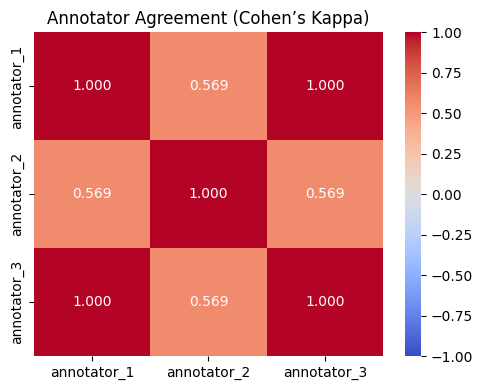

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

# Load annotators (latin-1 to avoid decode issues)
annotator_judge_1 = pd.read_csv("results/human/30_samples_annotator_1.csv", encoding="latin-1")
annotator_judge_2 = pd.read_csv("results/human/30_samples_annotator_2.csv", encoding="latin-1")
annotator_judge_3 = pd.read_csv("results/human/30_samples_annotator_3.csv", encoding="latin-1")

# Keep only the label column and align by index
df_annotators = pd.DataFrame({
    "annotator_1": annotator_judge_1["human_correct"],
    "annotator_2": annotator_judge_2["human_correct"],
    "annotator_3": annotator_judge_3["human_correct"],
})

# Remove empty/NaN rows
df_annotators = df_annotators.replace("", np.nan).dropna()

# Ensure numeric (0/1)
df_annotators = df_annotators.astype(int)

# Compute kappa matrix
kappa_matrix = pd.DataFrame(index=df_annotators.columns, columns=df_annotators.columns, dtype=float)
for a in kappa_matrix.index:
    for b in kappa_matrix.columns:
        kappa_matrix.loc[a, b] = 1.0 if a == b else cohen_kappa_score(df_annotators[a], df_annotators[b])

print("Pairwise Cohen’s kappa:\n", kappa_matrix)

# Plot heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(kappa_matrix.astype(float), annot=True, fmt=".3f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Annotator Agreement (Cohen’s Kappa)")
plt.tight_layout()
plt.savefig("AnnotationAgreement.png")
plt.show()

In [ ]:
import numpy as np
import krippendorff

# Stack annotator scores: shape (annotators, items)
data = np.vstack([
    annotator_judge_1['human_correct'].values,
    annotator_judge_2['human_correct'].values,
    annotator_judge_3['human_correct'].values
])

# Optional sanity checks
assert data.shape[0] == 3, "Expected 3 annotators"
assert set(np.unique(data[~np.isnan(data)])).issubset({0, 1}), \
       "Labels must be binary (0/1)"

# Compute Krippendorff's Alpha for nominal data
alpha = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement='nominal'
)

print("=" * 50)
print("Krippendorff's Alpha (Inter-Annotator Agreement)")
print("=" * 50)
print(f"Krippendorff's Alpha: {alpha:.4f}")


Krippendorff's Alpha (Inter-Annotator Agreement)
Krippendorff's Alpha: 0.7161


In [ ]:
import pandas as pd

def majority_label(row):
    votes = [row["ann1"], row["ann2"], row["ann3"]]
    zeros = votes.count(0)
    ones  = votes.count(1)
    if zeros > ones:
        return 0
    elif ones > zeros:
        return 1
    else:
        # perfect tie (should not happen with 3 votes unless NaNs); mark as None
        return None

def main():
    ann1 = pd.read_csv("results/human/30_samples_annotator_1.csv", encoding="latin-1")
    ann2 = pd.read_csv("results/human/30_samples_annotator_2.csv", encoding="latin-1")
    ann3 = pd.read_csv("results/human/30_samples_annotator_3.csv", encoding="latin-1")

    df = pd.DataFrame({
        "question": ann1["Question"],
        "ann1": ann1["human_correct"].astype(int),
        "ann2": ann2["human_correct"].astype(int),
        "ann3": ann3["human_correct"].astype(int),
    })

    df["majority_label"] = df.apply(majority_label, axis=1)
    df = df.dropna(subset=["majority_label"])  # drop ties/NaNs if any
    df["majority_label"] = df["majority_label"].astype(int)

    out_path = "results/human/final_ground_truth_majority.csv"
    df[["question", "majority_label"]].to_csv(out_path,index=False)
    print(f"Saved {len(df)} rows to {out_path}")

if __name__ == "__main__":
    main()

Saved 30 rows to results/human/final_ground_truth_majority.csv


# Result Analysis

In [3]:
import pandas as pd
import numpy as np
from glob import glob
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score

GT_PATH = "results/human/final_ground_truth_majority.csv"
MODEL_PATTERN = "ollama_gpt-oss_20b_judge_*.csv"  # adjust pattern if needed

def load_ground_truth(path=GT_PATH):
    gt = pd.read_csv(path)
    # normalize question column name
    if "question" in gt.columns and "Question" not in gt.columns:
        gt = gt.rename(columns={"question": "Question"})
    gt["question_text"] = gt["Question"]
    return gt[["question_text", "majority_label"]]

def aggregate_per_question(df):
    # majority vote over exploded rows for each question
    agg = df.groupby("question_text")["pred"].agg(lambda x: int(round(x.mean())))
    return agg.reset_index()

def evaluate(model_path, gt_df):
    df = pd.read_csv(model_path)

    # pick question column
    qcol = "questions" if "questions" in df.columns else ("Question" if "Question" in df.columns else None)
    if qcol is None:
        raise ValueError(f"No question column found in {model_path}")

    # pick prediction column
    if "correctness_score" in df.columns:
        pcol = "correctness_score"
    elif "pred" in df.columns:
        pcol = "pred"
    elif "output" in df.columns:
        # fallback: treat output as boolean-ish
        df["pred"] = df["output"].astype(str).str.lower().isin(["1", "true", "yes"])
        pcol = "pred"
    else:
        raise ValueError(f"No prediction column found in {model_path}")

    merged = df[[qcol, pcol]].rename(columns={qcol: "question_text", pcol: "pred"})
    merged["pred"] = merged["pred"].astype(float)
    merged = merged.merge(gt_df, on="question_text", how="inner")

    # per-line metrics (exploded rows)
    y_true = merged["majority_label"].astype(int)
    y_pred = merged["pred"].round().astype(int)
    line_acc = accuracy_score(y_true, y_pred)
    line_f1 = f1_score(y_true, y_pred)
    line_kappa = cohen_kappa_score(y_true, y_pred)

    # per-question aggregated metrics
    agg = aggregate_per_question(merged).merge(gt_df, on="question_text", how="inner")
    y_true_q = agg["majority_label"].astype(int)
    y_pred_q = agg["pred"].astype(int)
    q_acc = accuracy_score(y_true_q, y_pred_q)
    q_f1 = f1_score(y_true_q, y_pred_q)
    q_kappa = cohen_kappa_score(y_true_q, y_pred_q)

    return {
        "model_path": model_path,
        "n_rows_aligned": len(merged),
        "n_questions_aligned": len(agg),
        "line_accuracy": line_acc,
        "line_f1": line_f1,
        "line_kappa": line_kappa,
        "question_accuracy": q_acc,
        "question_f1": q_f1,
        "question_kappa": q_kappa,
    }

def main():
    gt_df = load_ground_truth()
    rows = []
    for path in glob(MODEL_PATTERN):
        rows.append(evaluate(path, gt_df))
    out = pd.DataFrame(rows)
    out.to_csv("results/human/model_eval_summary.csv", index=False)
    print(out)

if __name__ == "__main__":
    main()

                                          model_path  n_rows_aligned  \
0  ollama_gpt-oss_20b_judge_pipeline1_pollmultiho...              60   
1  ollama_gpt-oss_20b_judge_pipeline2_pollzerosho...              60   
2           ollama_gpt-oss_20b_judge_pipeline1_2.csv              30   
3  ollama_gpt-oss_20b_judge_pipeline1_pollkiltnq.csv              60   
4  ollama_gpt-oss_20b_judge_pipeline1_pollkilthot...              60   
5  ollama_gpt-oss_20b_judge_pipeline1_pollzerosho...              60   
6             ollama_gpt-oss_20b_judge_pipeline1.csv              30   

   n_questions_aligned  line_accuracy   line_f1  line_kappa  \
0                   30       0.400000  0.379310    0.013699   
1                   30       0.300000  0.125000   -0.028571   
2                   30       0.900000  0.869565    0.790698   
3                   30       0.300000  0.086957   -0.007194   
4                   30       0.300000  0.045455    0.013312   
5                   30       0.533333  0.5172

In [4]:
model_compare_human = pd.read_csv("results/human/model_eval_summary.csv")
model_compare_human.sort_values("question_f1")

,model_path,n_rows_aligned,n_questions_aligned,line_accuracy,line_f1,line_kappa,question_accuracy,question_f1,question_kappa
4,ollama_gpt-oss_20b_judge_pipeline1_pollkilthot...,60,30,0.300000,0.045455,0.013312,0.566667,0.000000,0.000000
3,ollama_gpt-oss_20b_judge_pipeline1_pollkiltnq.csv,60,30,0.300000,0.086957,-0.007194,0.566667,0.133333,0.020101
1,ollama_gpt-oss_20b_judge_pipeline2_pollzerosho...,60,30,0.300000,0.125000,-0.028571,0.566667,0.235294,0.039409
0,ollama_gpt-oss_20b_judge_pipeline1_pollmultiho...,60,30,0.400000,0.379310,0.013699,0.600000,0.454545,0.154930
5,ollama_gpt-oss_20b_judge_pipeline1_pollzerosho...,60,30,0.533333,0.517241,0.232877,0.866667,0.818182,0.718310
2,ollama_gpt-oss_20b_judge_pipeline1_2.csv,30,30,0.900000,0.869565,0.790698,0.900000,0.869565,0.790698
6,ollama_gpt-oss_20b_judge_pipeline1.csv,30,30,0.900000,0.869565,0.790698,0.900000,0.869565,0.790698


In [5]:
import pandas as pd

pipeline_1 = pd.read_csv("ollama_gpt-oss:20b_judge_pipeline1_pollzeroshot.csv")
pipeline_2 = pd.read_csv("ollama_gpt-oss:20b_judge_pipeline2_pollzeroshot.csv")

results_1 = pipeline_1[["correctness_score"]]
results_2 = pipeline_2[["correctness_score"]]

display(
    results_1.describe(),
    results_2.describe()
)


FileNotFoundError: [Errno 2] No such file or directory: 'ollama_gpt-oss:20b_judge_pipeline1_pollzeroshot.csv'